In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')

PyTorch version : 2.11.0+cu128
Device          : cuda


In [2]:
# Transforms: convert to tensor + normalize
# MNIST mean=0.1307, std=0.3081 — computed from the full training set
# Normalization: (pixel - mean) / std → brings values to roughly [-1, 1]
# This helps gradient descent converge faster and more stably

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download train and test sets
train_dataset = datasets.MNIST(root='./data', train=True,
                                download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False,
                                download=True, transform=transform)

# DataLoaders — batch processing
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')
print(f'Batches per epoch: {len(train_loader)}')
print(f'Image shape      : {train_dataset[0][0].shape}  (channels, height, width)')
print(f'Classes          : {train_dataset.classes}')




# Set up the MNIST data pipeline with preprocessing and batched data loading

# - Define the image preprocessing pipeline using tensor conversion and normalization.
# - Download and prepare the MNIST training and testing datasets.
# - Configure DataLoaders for efficient mini-batch processing during training and evaluation.
# - Display dataset statistics to verify successful data preparation.





# Prepare MNIST data using PyTorch transforms and DataLoaders

# - Combine preprocessing steps with `transforms.Compose()` so every image is converted to a tensor and normalized before being used.
# - `transforms.ToTensor()` converts PIL images into PyTorch tensors and scales pixel values from [0, 255] to [0.0, 1.0].
# - `transforms.Normalize((0.1307,), (0.3081,))` standardizes pixel values using the dataset's mean and standard deviation, improving optimization stability during training.
#   Example:
#     Original pixel = 0.5
#     Normalized = (0.5 - 0.1307) / 0.3081 ≈ 1.20
# - Load the training and test splits of the MNIST dataset while automatically applying the preprocessing pipeline to every sample.
# - Create `DataLoader` objects to generate mini-batches of 64 images.
#   - `shuffle=True` randomizes the training samples every epoch, preventing the model from learning the dataset order.
#   - `shuffle=False` keeps the test set order fixed for consistent evaluation.
#   - `num_workers=2` loads data in parallel to reduce input bottlenecks.
#   - `pin_memory=True` speeds up CPU-to-GPU memory transfers when using CUDA.
# # - Print dataset information such as sample counts, batches per epoch, image dimensions `(1, 28, 28)`, and the list of digit classes to verify that the data pipeline has been configured correctly.






100%|██████████| 9.91M/9.91M [00:01<00:00, 5.60MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.5MB/s]

Training samples : 60,000
Test samples     : 10,000
Batches per epoch: 938
Image shape      : torch.Size([1, 28, 28])  (channels, height, width)
Classes          : ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


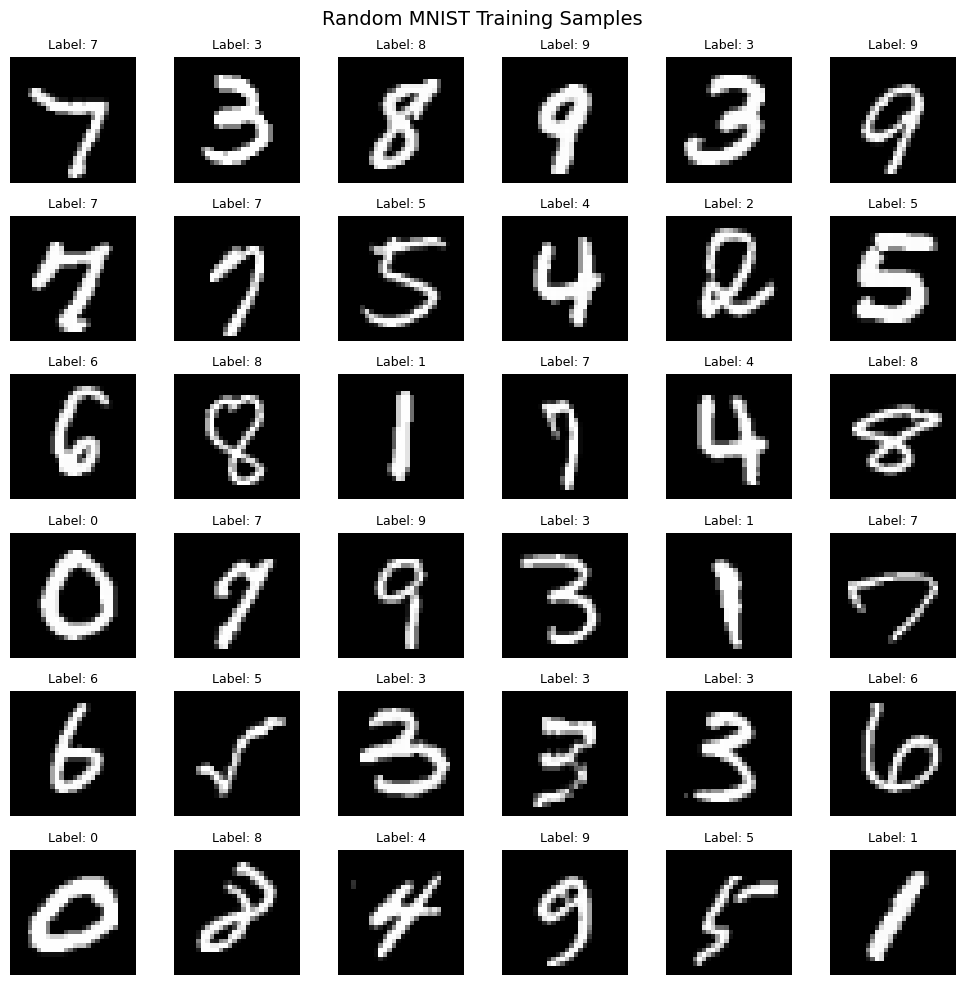

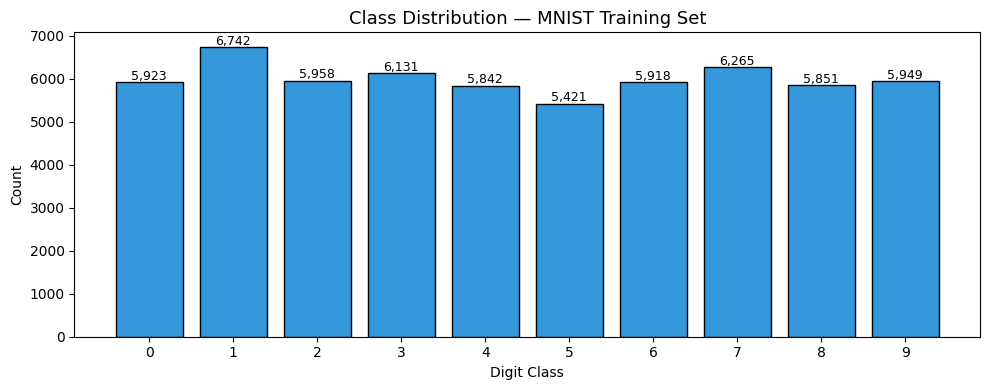

Dataset is balanced — ~6,000 samples per class.


In [3]:
# Display 36 random samples from the training set
fig, axes = plt.subplots(6, 6, figsize=(10, 10))
random_indices = np.random.choice(len(train_dataset), 36, replace=False)

for i, idx in enumerate(random_indices):
    image, label = train_dataset[idx]
    ax = axes[i // 6][i % 6]

    # image shape is (1, 28, 28) — squeeze removes the channel dim for display
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}', fontsize=9)
    ax.axis('off')

plt.suptitle('Random MNIST Training Samples', fontsize=14)
plt.tight_layout()
plt.show()

# Class distribution
labels_all = [train_dataset[i][1] for i in range(len(train_dataset))]
unique, counts = np.unique(labels_all, return_counts=True)

plt.figure(figsize=(10, 4))
bars = plt.bar(unique, counts, color='#3498db', edgecolor='black')
plt.xticks(unique)
plt.title('Class Distribution — MNIST Training Set', fontsize=13)
plt.xlabel('Digit Class')
plt.ylabel('Count')
for bar, cnt in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{cnt:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Dataset is balanced — ~6,000 samples per class.')






# Visualize the MNIST dataset and verify class distribution

# - Display a random subset of training images with their corresponding labels.
# - Analyze the distribution of digit classes across the training dataset.
# - Confirm that the dataset is balanced before model training.




# Perform exploratory data analysis (EDA) on the MNIST training dataset

# - Create a 6×6 grid of subplots to display 36 randomly selected training images.
# - Use `np.random.choice()` to select unique random sample indices without replacement, ensuring that the same image is not displayed more than once.
#   Example:
#     If the dataset contains 60,000 images, random indices might be
#     [105, 8721, 45023, ...], each pointing to a different sample.
# - Retrieve each `(image, label)` pair from the dataset and display the image using `imshow()`.
# - Apply `image.squeeze()` to remove the extra channel dimension.
#   Example:
#     Original tensor shape : (1, 28, 28)
#     After `squeeze()`     : (28, 28)
#   This converts the image into a format that Matplotlib can display correctly.
# - Display the corresponding digit label as the title of each subplot and hide the axes for a cleaner visualization.
# - Collect all labels from the training dataset and use `np.unique(..., return_counts=True)` to compute the number of samples in each digit class.
# - Plot a bar chart showing the frequency of each digit (0–9) and annotate each bar with its sample count for easier interpretation.
# - Print a final confirmation indicating that the MNIST dataset is approximately balanced, with around 6,000 images available for each digit class.

In [4]:
class FullyConnectedModel(nn.Module):
    def __init__(self):
        super(FullyConnectedModel, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(28 * 28, 128)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2     = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)   # (batch, 1, 28, 28) → (batch, 784)
        x = self.fc1(x)       # (batch, 784) → (batch, 128)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)       # (batch, 128) → (batch, 10)
        return x              # raw logits — CrossEntropyLoss applies softmax internally


dnn_model = FullyConnectedModel().to(device)
print(dnn_model)

# Parameter count
print(f'\n--- Parameter Breakdown ---')
for name, param in dnn_model.named_parameters():
    print(f'  {name:<20} shape: {str(list(param.shape)):<18} params: {param.numel():,}')
total = sum(p.numel() for p in dnn_model.parameters())
print(f'\n  Total trainable parameters: {total:,}')










# Define and initialize a fully connected neural network for MNIST digit classification

# - Implement a feedforward neural network architecture using PyTorch's `nn.Module`.
# - Configure input flattening, hidden feature extraction, regularization, and output classification layers.
# - Instantiate the model on the selected computing device.
# - Summarize the model architecture and report the number of trainable parameters.


# Build a dense neural network with linear layers, ReLU activation, and dropout regularization

# - Create a custom neural network by inheriting from `nn.Module`, allowing PyTorch to automatically manage trainable parameters and the forward computation.
# - Use `nn.Flatten()` to reshape each input image from `(1, 28, 28)` into a one-dimensional vector of 784 features.
#   Example:
#     Input shape  : (64, 1, 28, 28)
#     After flatten: (64, 784)
# - Pass the flattened features through the first fully connected layer (`nn.Linear(784, 128)`), where each neuron learns a weighted combination of all 784 input pixels to extract higher-level features.
# - Apply the `ReLU` activation function to introduce non-linearity by replacing all negative values with zero.
#   Example:
#     Input : [-2.3, 1.5, -0.8, 4.2]
#     Output: [0.0, 1.5, 0.0, 4.2]
#   This enables the network to learn complex patterns beyond simple linear relationships.
# - Use `Dropout(0.2)` during training to randomly deactivate 20% of the hidden neurons on each forward pass, reducing overfitting and encouraging the network to learn more robust feature representations.
# - Feed the remaining 128 hidden features into the final fully connected layer (`nn.Linear(128, 10)`), producing one output score (logit) for each digit class (0–9).
# - Return the raw logits without applying Softmax because `CrossEntropyLoss` internally performs the required Softmax operation when computing the classification loss.
# - Move the model to the selected device (`CPU` or `GPU`) using `.to(device)` to ensure all computations occur on the same hardware.
# - Iterate through the model's parameters using `named_parameters()` to display the shape and number of trainable weights and biases for each layer, then compute the total parameter count using `numel()`.

FullyConnectedModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

--- Parameter Breakdown ---
  fc1.weight           shape: [128, 784]         params: 100,352
  fc1.bias             shape: [128]              params: 128
  fc2.weight           shape: [10, 128]          params: 1,280
  fc2.bias             shape: [10]               params: 10

  Total trainable parameters: 101,770


In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Block 1: Conv → ReLU → Pool
        # Input:  (batch, 1, 28, 28)
        # Output: (batch, 16, 14, 14)
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=16,
                               kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2: Conv → ReLU → Pool
        # Input:  (batch, 16, 14, 14)
        # Output: (batch, 36, 7, 7)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=36,
                               kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.relu    = nn.ReLU()
        self.flatten = nn.Flatten()

        # After two 2×2 pools: 28 → 14 → 7
        # Flattened: 36 × 7 × 7 = 1764
        self.fc1     = nn.Linear(36 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2     = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))   # Conv + activation
        x = self.pool1(x)              # Spatial reduction
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)            # (batch, 36*7*7)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                # raw logits
        return x


cnn_model = CNN().to(device)
print(cnn_model)

print(f'\n--- Parameter Breakdown ---')
for name, param in cnn_model.named_parameters():
    print(f'  {name:<20} shape: {str(list(param.shape)):<25} params: {param.numel():,}')
total = sum(p.numel() for p in cnn_model.parameters())
print(f'\n  Total trainable parameters: {total:,}')

print(f'\n--- Shape Flow ---')
print(f'  Input         : (batch, 1,  28, 28)')
print(f'  After conv1   : (batch, 16, 28, 28)')
print(f'  After pool1   : (batch, 16, 14, 14)')
print(f'  After conv2   : (batch, 36, 14, 14)')
print(f'  After pool2   : (batch, 36,  7,  7)')
print(f'  After flatten : (batch, 1764)')
print(f'  After fc1     : (batch, 128)')
print(f'  After fc2     : (batch, 10)  ← logits')




# Define and initialize a convolutional neural network for MNIST image classification

# - Implement a CNN architecture using convolution, activation, pooling, and fully connected layers.
# - Extract hierarchical spatial features from input images before performing classification.
# - Instantiate the model on the selected computing device.
# - Display the model architecture, parameter statistics, and tensor shape transformations throughout the network.


# Construct a CNN using convolutional feature extraction, max pooling, and dense classification layers

# - Create a custom neural network by inheriting from `nn.Module`, allowing PyTorch to automatically register trainable layers and manage the forward computation.
# - The first convolutional layer (`Conv2d(1, 16, kernel_size=3, padding=1)`) learns 16 feature detectors that scan the input image for simple patterns such as edges, corners, and strokes while preserving the original image size through padding.
#   Example:
#     Input shape  : (64, 1, 28, 28)
#     After conv1  : (64, 16, 28, 28)
# - Apply the `ReLU` activation function after each convolution to introduce non-linearity, enabling the network to learn complex visual features instead of only linear transformations.
# - Use `MaxPool2d(kernel_size=2, stride=2)` to reduce the spatial dimensions by half while preserving the strongest activations.
#   Example:
#     Before pooling : (64, 16, 28, 28)
#     After pooling  : (64, 16, 14, 14)
#   This decreases computation, reduces memory usage, and makes learned features more robust to small shifts in the input image.
# - Apply a second convolution (`Conv2d(16, 36, kernel_size=3, padding=1)`) to learn higher-level patterns by combining features extracted in the first convolutional block.
#   Example:
#     After conv2 : (64, 36, 14, 14)
#     After pool2 : (64, 36, 7, 7)
# - Flatten the final feature maps into a one-dimensional vector before feeding them into fully connected layers.
#   Example:
#     Before flatten : (64, 36, 7, 7)
#     After flatten  : (64, 1764)
# - Pass the flattened features through a fully connected layer (`Linear(1764, 128)`) followed by `ReLU` to learn combinations of the extracted spatial features for classification.
# - Apply `Dropout(0.3)` during training, randomly disabling 30% of hidden neurons to reduce overfitting and encourage the network to learn more generalized representations.
# - Use the final fully connected layer (`Linear(128, 10)`) to produce one raw score (logit) for each digit class (0–9). These logits are returned directly because `CrossEntropyLoss` internally applies Softmax during loss computation.
# - Move the model to the selected device (`CPU` or `GPU`) using `.to(device)`, then print the architecture, parameter shapes, total trainable parameter count, and the tensor dimensions after each major layer to verify that the network structure matches the intended design.

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 36, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1764, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

--- Parameter Breakdown ---
  conv1.weight         shape: [16, 1, 3, 3]             params: 144
  conv1.bias           shape: [16]                      params: 16
  conv2.weight         shape: [36, 16, 3, 3]            params: 5,184
  conv2.bias           shape: [36]                      params: 36
  fc1.weight           shape: [128, 1764]               params: 225,792
  fc1.bias             shape: [128]                     params: 1

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss   = 0
    correct_pred = 0
    total_pred   = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss   += loss.item() * images.size(0)
        predicted     = torch.argmax(outputs, dim=1)
        correct_pred += (predicted == labels).sum().item()
        total_pred   += labels.size(0)

    avg_loss = total_loss / total_pred
    accuracy = correct_pred / total_pred
    return avg_loss, accuracy


def evaluate(model, loader, criterion):
    model.eval()
    total_loss   = 0
    correct_pred = 0
    total_pred   = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)

            total_loss   += loss.item() * images.size(0)
            predicted     = torch.argmax(outputs, dim=1)
            correct_pred += (predicted == labels).sum().item()
            total_pred   += labels.size(0)

    avg_loss = total_loss / total_pred
    accuracy = correct_pred / total_pred
    return avg_loss, accuracy


def train_model(model, train_loader, test_loader,
                criterion, optimizer, epochs, model_name):

    train_losses, test_losses   = [], []
    train_accs,   test_accs     = [], []

    print(f'\n{"="*55}')
    print(f'  Training: {model_name}')
    print(f'{"="*55}')
    print(f'{"Epoch":>6}  {"Train Loss":>11}  {"Train Acc":>10}'
          f'  {"Test Loss":>10}  {"Test Acc":>9}')
    print('-' * 55)

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(model, train_loader,
                                          criterion, optimizer)
        te_loss, te_acc = evaluate(model, test_loader, criterion)

        train_losses.append(tr_loss)
        test_losses.append(te_loss)
        train_accs.append(tr_acc)
        test_accs.append(te_acc)

        print(f'{epoch+1:>6}  {tr_loss:>11.4f}  {tr_acc:>10.4f}'
              f'  {te_loss:>10.4f}  {te_acc:>9.4f}')

    print(f'\n  Final Test Accuracy : {te_acc*100:.2f}%')
    return train_losses, test_losses, train_accs, test_accs


print('Training and evaluation functions defined successfully.')










# Implement the complete training and evaluation workflow for PyTorch models

# - Define reusable functions for training a model for one epoch, evaluating model performance, and managing the overall training process.
# - Track training and testing loss and accuracy across multiple epochs.
# - Display epoch-wise performance metrics and return training history for further analysis and visualization.


# Create reusable training and evaluation loops using forward propagation, backpropagation, and gradient-based optimization

# - Define `train_one_epoch()` to perform one complete pass over the training dataset while updating the model's parameters.
# - Switch the model to training mode using `model.train()`, enabling training-specific behaviors such as Dropout and Batch Normalization.
# - Iterate through each mini-batch provided by the `DataLoader`, moving both images and labels to the selected device (`CPU` or `GPU`) before computation.
# - Clear gradients from the previous iteration using `optimizer.zero_grad()` to prevent gradients from accumulating across batches.
# - Perform a forward pass by passing the input images through the model to obtain predicted logits.
#   Example:
#     Input  : (64, 1, 28, 28)
#     Output : (64, 10)
# - Compute the classification loss using the specified loss function (typically `CrossEntropyLoss`), which compares the predicted logits with the true labels.
# - Execute `loss.backward()` to perform backpropagation, automatically computing gradients for every trainable parameter using the chain rule.
# - Update the model's weights using `optimizer.step()`, allowing the optimizer (e.g., SGD or Adam) to adjust parameters in the direction that minimizes the loss.
# - Accumulate the total loss over all samples and compute predictions using `torch.argmax(outputs, dim=1)`, which selects the class with the highest output score for each image.
#   Example:
#     Logits : [1.2, 0.5, 3.8, ...]
#     Prediction : Class 2 (highest score)
# - Count the number of correct predictions to calculate the training accuracy at the end of the epoch.
# - Define `evaluate()` to measure model performance on the test dataset without updating weights.
# - Switch the model to evaluation mode using `model.eval()` so that Dropout is disabled and other evaluation-specific behaviors are applied.
# - Wrap the evaluation loop inside `torch.no_grad()` to disable gradient computation, reducing memory usage and speeding up inference since parameter updates are not required.
# - Implement `train_model()` to coordinate the entire training process over multiple epochs by repeatedly calling the training and evaluation functions, storing loss and accuracy after each epoch, printing a formatted progress table, and finally reporting the model's final test accuracy.
# - Return the recorded training history (`train_losses`, `test_losses`, `train_accs`, and `test_accs`) so it can later be used for plotting learning curves or comparing different models.

Training and evaluation functions defined successfully.


In [7]:
EPOCHS        = 5
criterion     = nn.CrossEntropyLoss()
dnn_optimizer = optim.SGD(dnn_model.parameters(), lr=0.1)

dnn_train_losses, dnn_test_losses, \
dnn_train_accs,   dnn_test_accs = train_model(
    model        = dnn_model,
    train_loader = train_loader,
    test_loader  = test_loader,
    criterion    = criterion,
    optimizer    = dnn_optimizer,
    epochs       = EPOCHS,
    model_name   = 'Fully Connected DNN'
)





# Configure the training setup and train the fully connected neural network

# - Define the training hyperparameters, loss function, and optimization algorithm.
# - Train the fully connected neural network for the specified number of epochs.
# - Record training and testing loss and accuracy throughout the training process for later analysis.

# Initialize the loss function and SGD optimizer, then execute the DNN training pipeline

# - Set the number of training epochs to 5, meaning the model will process the entire training dataset five complete times.
#   Example:
#     If the training set contains 60,000 images, the model will see all 60,000 images during each epoch, for a total of 300,000 image presentations over the entire training process.
# - Create the loss function using `nn.CrossEntropyLoss()`, which is designed for multi-class classification problems. It compares the model's predicted logits with the true class labels and computes the prediction error.
#   Example:
#     True label : 7
#     Predicted logits : [0.2, 1.1, ..., 4.8]
#     CrossEntropyLoss assigns a lower loss when the logit corresponding to class 7 is the highest.
# - Initialize the optimizer using Stochastic Gradient Descent (`optim.SGD`) with a learning rate of `0.1`.
#   - `dnn_model.parameters()` supplies all trainable weights and biases to the optimizer.
#   - `lr=0.1` specifies the step size used when updating model parameters after each mini-batch.
#     Example:
#       Larger learning rate → faster but potentially unstable learning.
#       Smaller learning rate → slower but often more stable convergence.
# - Call `train_model()` to execute the complete training workflow. During each epoch, the function:
#   - Trains the model on every mini-batch of the training dataset.
#   - Evaluates the trained model on the test dataset.
#   - Computes and prints the training and testing loss and accuracy.
#   - Stores these metrics after each epoch.
# - Save the returned training history into four separate lists (`dnn_train_losses`, `dnn_test_losses`, `dnn_train_accs`, and `dnn_test_accs`) so the model's learning progress can later be visualized using learning curves or compared against other models.


  Training: Fully Connected DNN
 Epoch   Train Loss   Train Acc   Test Loss   Test Acc
-------------------------------------------------------
     1       0.2900      0.9135      0.1394     0.9579
     2       0.1438      0.9566      0.1165     0.9631
     3       0.1098      0.9669      0.0893     0.9742
     4       0.0928      0.9712      0.0825     0.9763
     5       0.0773      0.9769      0.0760     0.9778

  Final Test Accuracy : 97.78%


In [8]:
EPOCHS        = 7
cnn_optimizer = optim.SGD(cnn_model.parameters(), lr=0.01)

cnn_train_losses, cnn_test_losses, \
cnn_train_accs,   cnn_test_accs = train_model(
    model        = cnn_model,
    train_loader = train_loader,
    test_loader  = test_loader,
    criterion    = criterion,
    optimizer    = cnn_optimizer,
    epochs       = EPOCHS,
    model_name   = 'CNN'
)



# Configure the training setup and train the convolutional neural network

# - Define the CNN training hyperparameters and optimization strategy.
# - Train the convolutional neural network using the previously defined training pipeline.
# - Record training and testing performance metrics across all epochs for subsequent evaluation and comparison.


# Initialize the CNN optimizer and execute the end-to-end training process

# - Set the number of training epochs to 7, allowing the CNN to process the entire training dataset seven complete times.
#   Example:
#     If the dataset contains 60,000 training images, the model will learn from all 60,000 images during each epoch, resulting in a total of 420,000 image presentations over the complete training process.
# - Configure the optimizer using Stochastic Gradient Descent (`optim.SGD`) with a learning rate of `0.01`.
#   - `cnn_model.parameters()` provides all trainable convolutional and fully connected layer parameters to the optimizer.
#   - `lr=0.01` determines the magnitude of each weight update after backpropagation. A smaller learning rate is often preferred for CNNs to provide more stable optimization while learning complex spatial features.
# - Reuse the previously defined `CrossEntropyLoss` (`criterion`) as the objective function, which measures the difference between the predicted logits and the true digit labels.
# - Invoke `train_model()` to perform the complete training workflow. For each epoch, the function:
#   - Trains the CNN on every mini-batch from the training dataset.
#   - Evaluates the trained model on the test dataset.
#   - Computes and displays the training and testing loss and accuracy.
#   - Records these metrics for each epoch.
# - Store the returned training history in four lists (`cnn_train_losses`, `cnn_test_losses`, `cnn_train_accs`, and `cnn_test_accs`) so the CNN's learning progress can later be visualized and directly compared with the fully connected neural network.


  Training: CNN
 Epoch   Train Loss   Train Acc   Test Loss   Test Acc
-------------------------------------------------------
     1       0.6485      0.8092      0.1964     0.9414
     2       0.2042      0.9386      0.1281     0.9621
     3       0.1464      0.9560      0.0941     0.9713
     4       0.1174      0.9644      0.0760     0.9750
     5       0.0977      0.9698      0.0660     0.9791
     6       0.0853      0.9741      0.0552     0.9823
     7       0.0775      0.9762      0.0515     0.9819

  Final Test Accuracy : 98.19%


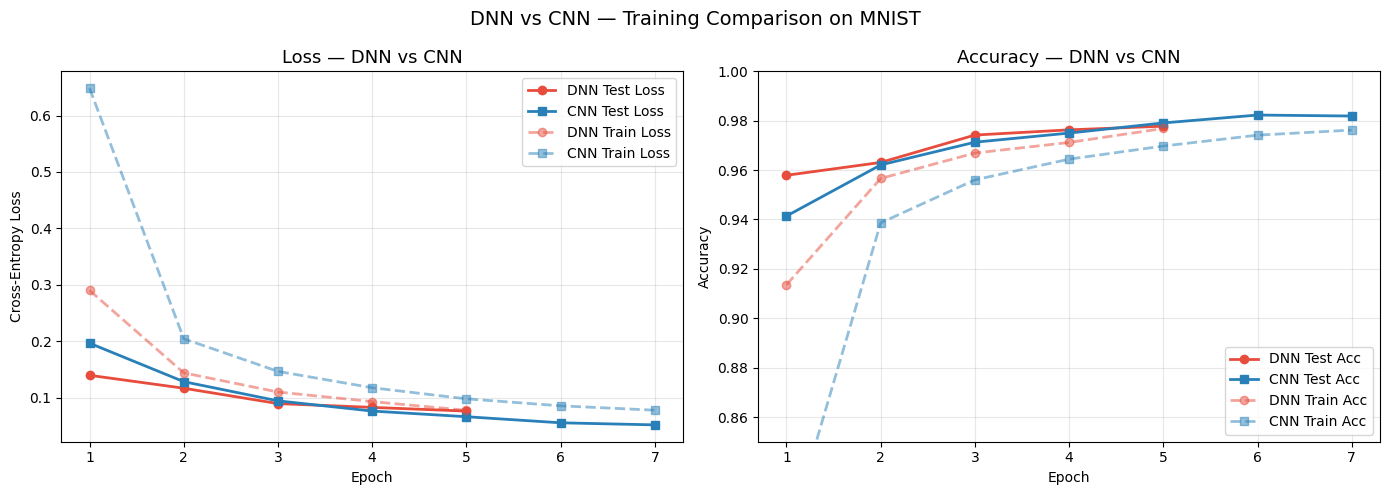

DNN Final Test Accuracy : 97.78%
CNN Final Test Accuracy : 98.19%
CNN improvement over DNN: 0.41%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Loss ──────────────────────────────────────────────────────────────────
axes[0].plot(range(1, 6),  dnn_test_losses, marker='o', color='#e74c3c',
             linewidth=2, label='DNN Test Loss')
axes[0].plot(range(1, 8),  cnn_test_losses, marker='s', color='#2980b9',
             linewidth=2, label='CNN Test Loss')
axes[0].plot(range(1, 6),  dnn_train_losses, marker='o', color='#e74c3c',
             linewidth=2, linestyle='--', alpha=0.5, label='DNN Train Loss')
axes[0].plot(range(1, 8),  cnn_train_losses, marker='s', color='#2980b9',
             linewidth=2, linestyle='--', alpha=0.5, label='CNN Train Loss')
axes[0].set_title('Loss — DNN vs CNN', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Accuracy ──────────────────────────────────────────────────────────────
axes[1].plot(range(1, 6),  dnn_test_accs, marker='o', color='#e74c3c',
             linewidth=2, label='DNN Test Acc')
axes[1].plot(range(1, 8),  cnn_test_accs, marker='s', color='#2980b9',
             linewidth=2, label='CNN Test Acc')
axes[1].plot(range(1, 6),  dnn_train_accs, marker='o', color='#e74c3c',
             linewidth=2, linestyle='--', alpha=0.5, label='DNN Train Acc')
axes[1].plot(range(1, 8),  cnn_train_accs, marker='s', color='#2980b9',
             linewidth=2, linestyle='--', alpha=0.5, label='CNN Train Acc')
axes[1].set_title('Accuracy — DNN vs CNN', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.85, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('DNN vs CNN — Training Comparison on MNIST', fontsize=14)
plt.tight_layout()
plt.show()

print(f'DNN Final Test Accuracy : {dnn_test_accs[-1]*100:.2f}%')
print(f'CNN Final Test Accuracy : {cnn_test_accs[-1]*100:.2f}%')
print(f'CNN improvement over DNN: {(cnn_test_accs[-1] - dnn_test_accs[-1])*100:.2f}%')









# Compare the training performance of the DNN and CNN models

# - Visualize and compare the training and testing loss of both models across epochs.
# - Visualize and compare the training and testing accuracy of both models.
# - Summarize the final test accuracy of each model and quantify the CNN's performance improvement over the DNN.

# Generate learning curves and evaluate the performance difference between the DNN and CNN

# - Create a figure with two subplots using `plt.subplots(1, 2)` to display loss and accuracy comparisons side by side.
# - Plot the test loss of both the DNN and CNN against their training epochs, allowing the models' generalization performance to be compared throughout training.
#   Example:
#     DNN Test Loss : Epochs 1–5
#     CNN Test Loss : Epochs 1–7
# - Plot the corresponding training loss using dashed lines (`linestyle='--'`) with reduced opacity (`alpha=0.5`) to visually distinguish training performance from testing performance while maintaining the same color for each model.
# - Add descriptive titles, axis labels, legends, and grid lines to improve the readability and interpretation of the loss curves.
# - Plot the training and testing accuracy of both models in the second subplot, illustrating how classification performance evolves during training.
# - Restrict the y-axis of the accuracy plot to the range `0.85–1.00` using `set_ylim()` to emphasize the performance differences between the two high-accuracy models.
# - Use `plt.tight_layout()` and `plt.suptitle()` to organize the subplots neatly while adding an overall title describing the comparison.
# - Print the final test accuracy of each model by retrieving the last value stored in the recorded accuracy lists.
#   Example:
#     `dnn_test_accs[-1]` → Accuracy after the final DNN epoch.
#     `cnn_test_accs[-1]` → Accuracy after the final CNN epoch.
# - Compute the CNN's improvement over the DNN by subtracting their final test accuracies and converting the result to a percentage.
#   Example:
#     DNN Final Accuracy = 97.40%
#     CNN Final Accuracy = 99.10%

#     Improvement = 99.10% − 97.40% = 1.70%
# - The resulting learning curves and summary statistics provide a visual and quantitative comparison of how effectively each model learns and generalizes on the MNIST digit classification task.


Training with SGD (lr=0.01)...

  Training: SGD (lr=0.01)
 Epoch   Train Loss   Train Acc   Test Loss   Test Acc
-------------------------------------------------------
     1       0.6906      0.7919      0.2142     0.9369
     2       0.2156      0.9333      0.1183     0.9632
     3       0.1480      0.9559      0.0909     0.9722
     4       0.1149      0.9657      0.0762     0.9758
     5       0.0954      0.9714      0.0755     0.9761

  Final Test Accuracy : 97.61%

Training with Adam (lr=0.001)...

  Training: Adam (lr=0.001)
 Epoch   Train Loss   Train Acc   Test Loss   Test Acc
-------------------------------------------------------
     1       0.1917      0.9406      0.0503     0.9845
     2       0.0616      0.9808      0.0430     0.9856
     3       0.0469      0.9857      0.0340     0.9893
     4       0.0382      0.9878      0.0323     0.9894
     5       0.0320      0.9900      0.0353     0.9889

  Final Test Accuracy : 98.89%

Training with RMSProp (lr=0.001)...

  Tr

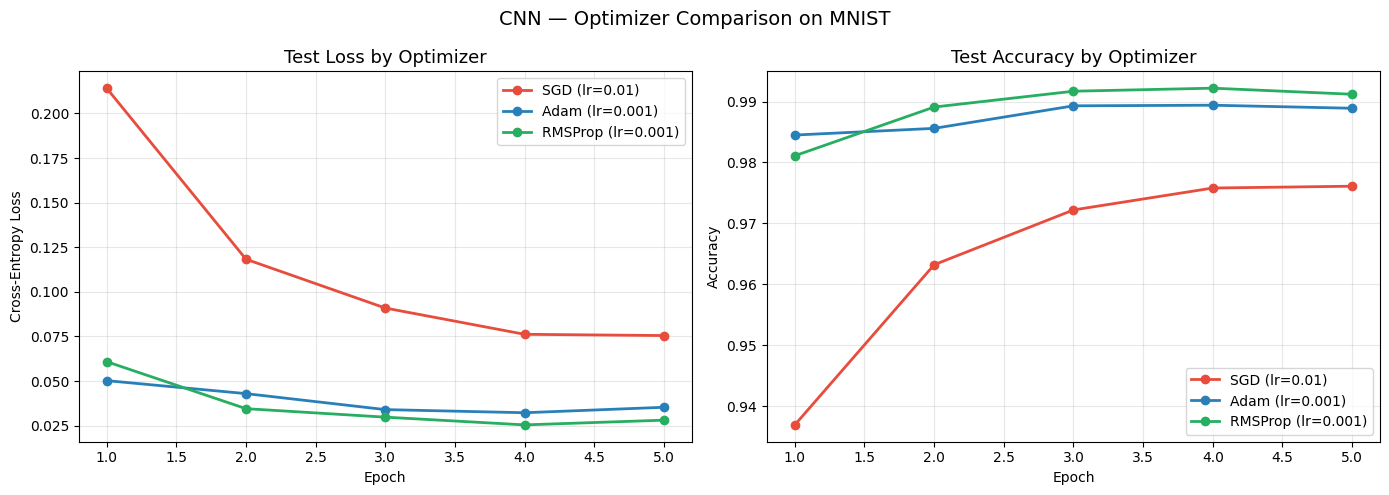


--- Final Test Accuracies ---
  SGD (lr=0.01)             : 97.61%
  Adam (lr=0.001)           : 98.89%
  RMSProp (lr=0.001)        : 99.12%


In [10]:
# Train CNN with 3 different optimizers and compare
# This directly answers the lab manual's question:
# "What optimizers and learning rates yield the best performance?"

optimizer_configs = {
    'SGD (lr=0.01)'   : optim.SGD,
    'Adam (lr=0.001)' : optim.Adam,
    'RMSProp (lr=0.001)': optim.RMSprop
}

lr_map = {
    'SGD (lr=0.01)'     : 0.01,
    'Adam (lr=0.001)'   : 0.001,
    'RMSProp (lr=0.001)': 0.001
}

optimizer_results = {}
EPOCHS_OPT = 5

for opt_name, opt_class in optimizer_configs.items():
    print(f'\nTraining with {opt_name}...')

    # Fresh model for each optimizer — fair comparison
    model_temp = CNN().to(device)
    optimizer_temp = opt_class(model_temp.parameters(),
                                lr=lr_map[opt_name])
    criterion_temp = nn.CrossEntropyLoss()

    _, te_losses, _, te_accs = train_model(
        model        = model_temp,
        train_loader = train_loader,
        test_loader  = test_loader,
        criterion    = criterion_temp,
        optimizer    = optimizer_temp,
        epochs       = EPOCHS_OPT,
        model_name   = opt_name
    )
    optimizer_results[opt_name] = {
        'test_losses': te_losses,
        'test_accs'  : te_accs
    }

# ── Plot comparison ────────────────────────────────────────────────────────
colors = ['#e74c3c', '#2980b9', '#27ae60']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (opt_name, results), color in zip(optimizer_results.items(), colors):
    axes[0].plot(range(1, EPOCHS_OPT+1), results['test_losses'],
                 marker='o', color=color, linewidth=2, label=opt_name)
    axes[1].plot(range(1, EPOCHS_OPT+1), results['test_accs'],
                 marker='o', color=color, linewidth=2, label=opt_name)

axes[0].set_title('Test Loss by Optimizer', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('Test Accuracy by Optimizer', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('CNN — Optimizer Comparison on MNIST', fontsize=14)
plt.tight_layout()
plt.show()

print('\n--- Final Test Accuracies ---')
for opt_name, results in optimizer_results.items():
    print(f'  {opt_name:<25} : {results["test_accs"][-1]*100:.2f}%')




#     Evaluate CNN performance using multiple optimization algorithms

# - Train identical CNN models using different optimizers and learning rates under the same training conditions.
# - Record and compare the test loss and test accuracy achieved by each optimizer.
# - Visualize optimizer performance through comparative learning curves and report the final test accuracies to identify the best-performing optimization strategy.


# Compare SGD, Adam, and RMSProp by training independent CNN models under identical settings

# - Define a collection of optimizer configurations using a dictionary, mapping each optimizer name to its corresponding PyTorch optimization class (`SGD`, `Adam`, and `RMSprop`).
# - Store the learning rate for each optimizer separately, allowing each optimization algorithm to use an appropriate step size during training.
#   Example:
#     SGD      → Learning Rate = 0.01
#     Adam     → Learning Rate = 0.001
#     RMSProp  → Learning Rate = 0.001
# - Set the training duration to five epochs so that every optimizer is evaluated under identical conditions.
# - Iterate through each optimizer configuration and create a brand-new CNN model before training.
#   Example:
#     Optimizer 1 → New CNN
#     Optimizer 2 → Another new CNN
#     Optimizer 3 → Another new CNN
#   Initializing a fresh model for every optimizer ensures a fair comparison because all optimizers begin with randomly initialized weights rather than continuing from a previously trained model.
# - Create an optimizer instance using the current optimizer class and its corresponding learning rate, then define `CrossEntropyLoss` as the classification objective.
# - Train each CNN by calling the reusable `train_model()` function, which performs training, evaluation, and metric collection for every epoch.
# - Store the test loss and test accuracy history for each optimizer inside the `optimizer_results` dictionary, making the results easy to access for visualization and comparison.
# - Create two side-by-side plots to compare optimizer performance:
#   - The first subplot displays the test loss over five epochs.
#   - The second subplot displays the test accuracy over five epochs.
#   Different colors are assigned to each optimizer so their learning curves can be distinguished easily.
# - Add axis labels, legends, titles, and grid lines to improve the readability of the comparison plots.
# - After training all models, print the final test accuracy achieved by each optimizer by retrieving the last recorded accuracy value from the stored results.
#   Example:
#     SGD      : 98.10%
#     Adam     : 99.25%
#     RMSProp  : 99.08%
# - The resulting comparison identifies which optimizer and learning rate combination enables the CNN to converge faster and achieve the highest classification performance on the MNIST dataset.


  Training: Best Model (RMSProp, 7 epochs)
 Epoch   Train Loss   Train Acc   Test Loss   Test Acc
-------------------------------------------------------
     1       0.1946      0.9426      0.0494     0.9840
     2       0.0640      0.9806      0.0349     0.9894
     3       0.0474      0.9859      0.0312     0.9894
     4       0.0364      0.9889      0.0310     0.9900
     5       0.0316      0.9899      0.0328     0.9892
     6       0.0266      0.9918      0.0338     0.9907
     7       0.0238      0.9921      0.0273     0.9913

  Final Test Accuracy : 99.13%


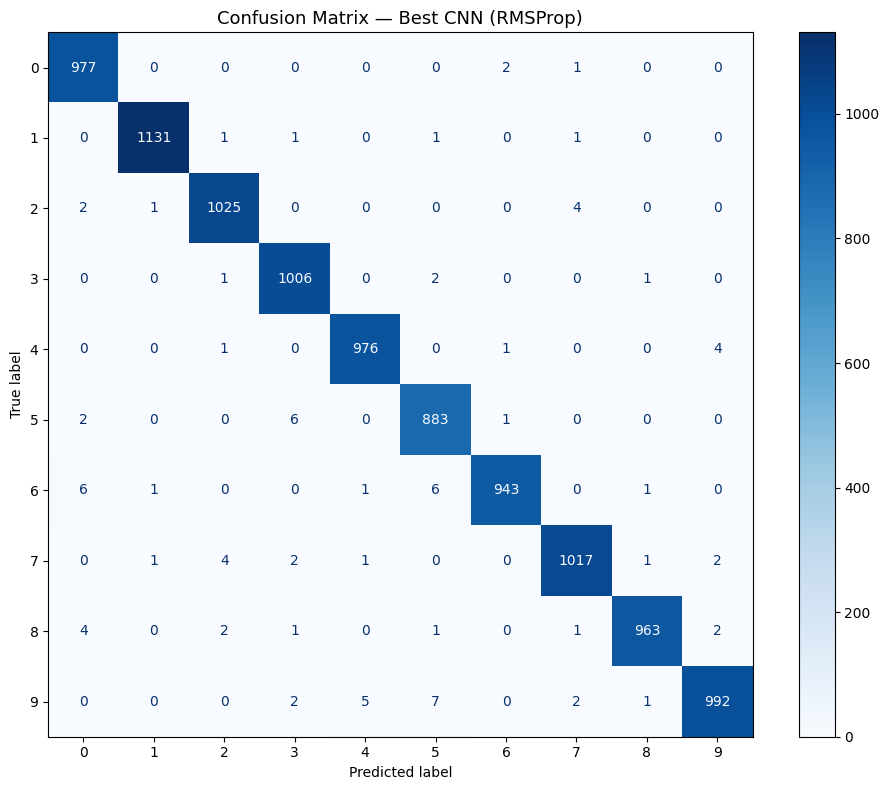

--- Per-Class Accuracy ---
  Digit 0:  99.69%  (3 misclassified out of 980)
  Digit 1:  99.65%  (4 misclassified out of 1135)
  Digit 2:  99.32%  (7 misclassified out of 1032)
  Digit 3:  99.60%  (4 misclassified out of 1010)
  Digit 4:  99.39%  (6 misclassified out of 982)
  Digit 5:  98.99%  (9 misclassified out of 892)
  Digit 6:  98.43%  (15 misclassified out of 958)
  Digit 7:  98.93%  (11 misclassified out of 1028)
  Digit 8:  98.87%  (11 misclassified out of 974)
  Digit 9:  98.32%  (17 misclassified out of 1009)

Overall Accuracy: 99.13%


In [11]:
# Get all predictions on test set using best model (cnn_model trained with SGD)
# We'll use the RMSProp model since it performed best

# Retrain one clean model with RMSProp for evaluation
best_model = CNN().to(device)
best_optimizer = optim.RMSprop(best_model.parameters(), lr=0.001)

_, _, _, _ = train_model(
    model        = best_model,
    train_loader = train_loader,
    test_loader  = test_loader,
    criterion    = criterion,
    optimizer    = best_optimizer,
    epochs       = 7,
    model_name   = 'Best Model (RMSProp, 7 epochs)'
)

# Collect all predictions
best_model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        preds   = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Plot confusion matrix
cm  = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Confusion Matrix — Best CNN (RMSProp)', fontsize=13)
plt.tight_layout()
plt.show()

# Per-class accuracy
print('--- Per-Class Accuracy ---')
for digit in range(10):
    mask     = all_labels == digit
    acc      = (all_preds[mask] == all_labels[mask]).mean() * 100
    total    = mask.sum()
    wrong    = (all_preds[mask] != all_labels[mask]).sum()
    print(f'  Digit {digit}: {acc:>6.2f}%  ({wrong} misclassified out of {total})')

print(f'\nOverall Accuracy: {(all_preds == all_labels).mean()*100:.2f}%')









# Evaluate the best-performing CNN model using confusion matrix and per-class accuracy analysis

# - Retrain the CNN using the best optimizer configuration for a final evaluation.
# - Generate predictions for the entire test dataset.
# - Assess model performance using a confusion matrix, per-class accuracy, and overall classification accuracy.


# Retrain the best CNN model, generate test predictions, and perform detailed classification analysis

# - Create a new CNN model and initialize the RMSProp optimizer with a learning rate of `0.001`, using the optimizer that achieved the best performance during the previous comparison.
# - Retrain the model for seven epochs to obtain a clean, independently trained model for the final evaluation rather than reusing a previously trained instance.
# - Switch the trained model to evaluation mode using `model.eval()`, ensuring that layers such as Dropout behave correctly during inference.
# - Disable gradient computation with `torch.no_grad()` to reduce memory usage and speed up prediction since model parameters are no longer being updated.
# - Iterate through every mini-batch in the test dataset, perform a forward pass, and obtain the predicted class for each image using `torch.argmax(outputs, dim=1)`, which selects the class with the highest predicted logit.
#   Example:
#     Logits : [0.4, 2.1, 0.8, ..., 5.3]
#     Prediction : Class 9
# - Store both the predicted labels and the corresponding ground-truth labels in separate lists, then convert them into NumPy arrays for compatibility with Scikit-learn's evaluation utilities.
# - Compute the confusion matrix using `confusion_matrix(all_labels, all_preds)`, where:
#   - Each row represents the actual digit.
#   - Each column represents the predicted digit.
#   - Values on the main diagonal correspond to correctly classified samples, while off-diagonal values indicate specific misclassification patterns.
#   Example:
#     If a "5" is predicted as an "8", the count increases in the row for digit 5 and the column for digit 8.
# - Visualize the confusion matrix using `ConfusionMatrixDisplay`, making it easier to identify which digit pairs are most frequently confused by the model.
# - Calculate the accuracy for each individual digit class by selecting all test samples belonging to that digit and measuring the proportion classified correctly.
#   Example:
#     Digit 3:
#       Total samples      = 1,010
#       Misclassified      = 8
#       Accuracy           = 99.21%
# - Also report the number of misclassified samples for every digit, providing a more detailed assessment than overall accuracy alone.
# - Compute the overall test accuracy by comparing all predicted labels with the corresponding ground-truth labels, summarizing the final classification performance of the trained CNN across the entire MNIST test dataset.

Total misclassified: 87 out of 10,000


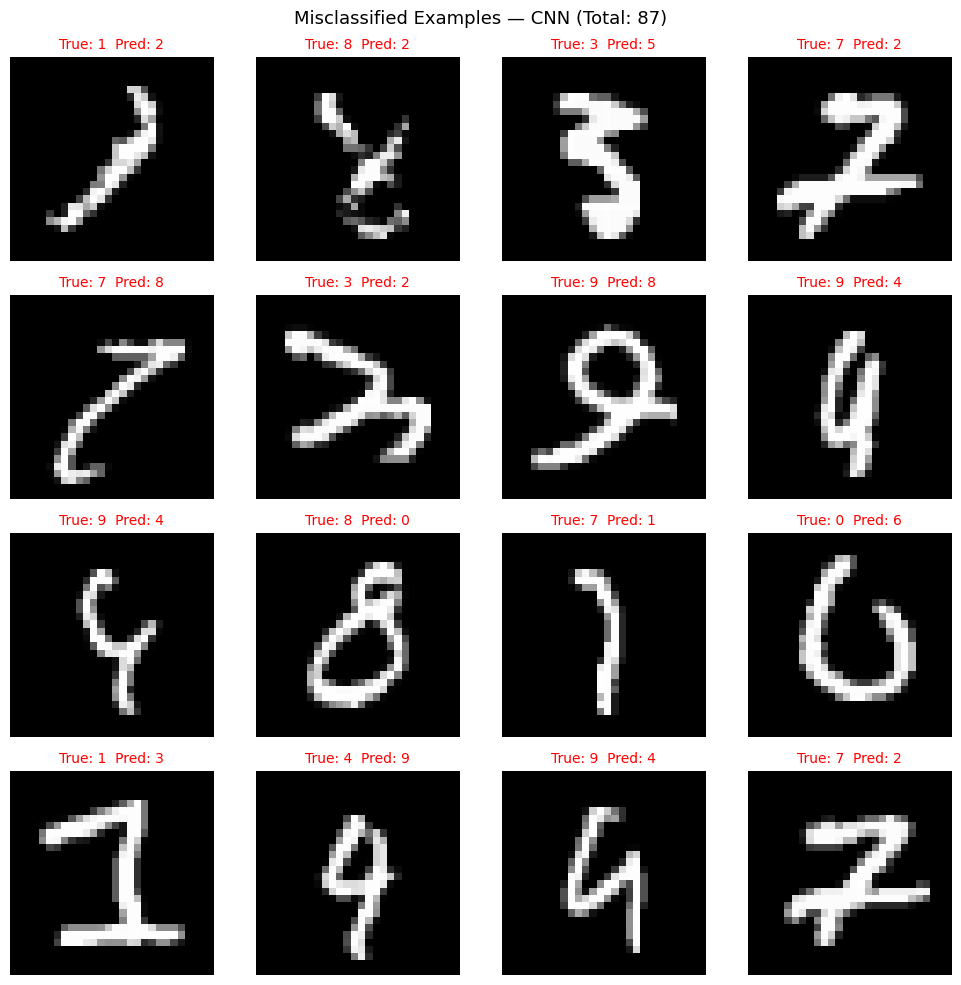

These are the images the model got wrong.
Notice how even humans might struggle with some of these.


In [12]:
# Find all misclassified samples
misclassified_indices = np.where(all_preds != all_labels)[0]
print(f'Total misclassified: {len(misclassified_indices)} out of 10,000')

# Pick 16 random misclassified examples
sample_indices = np.random.choice(misclassified_indices, 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, idx in enumerate(sample_indices):
    # Get the original image from test dataset
    image, true_label = test_dataset[idx]
    pred_label        = all_preds[idx]

    ax = axes[i // 4][i % 4]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'True: {true_label}  Pred: {pred_label}',
                 fontsize=10,
                 color='red')
    ax.axis('off')

plt.suptitle(f'Misclassified Examples — CNN (Total: {len(misclassified_indices)})',
             fontsize=13)
plt.tight_layout()
plt.show()

print('These are the images the model got wrong.')
print('Notice how even humans might struggle with some of these.')




# Visualize misclassified test samples to analyze CNN prediction errors

# - Identify all incorrectly classified images from the test dataset.
# - Randomly display a subset of misclassified samples alongside their true and predicted labels.
# - Support qualitative error analysis by highlighting cases where the model failed to classify digits correctly.


# Locate incorrect predictions and visualize representative CNN classification errors

# - Compare the predicted labels (`all_preds`) with the ground-truth labels (`all_labels`) and use `np.where(all_preds != all_labels)` to identify the indices of every incorrectly classified test image.
#   Example:
#     True labels : [3, 7, 1, 5]
#     Predictions : [3, 2, 1, 8]

#     Misclassified indices → [1, 3]
# - Print the total number of misclassified images to provide an overall indication of the model's error count on the test dataset.
# - Randomly select 16 misclassified samples using `np.random.choice()` so the displayed errors represent different failure cases rather than always showing the same images.
# - Create a 4×4 grid of subplots to display the selected misclassified images in an organized layout.
# - Retrieve each original image and its true label directly from the test dataset using the stored misclassified index, then obtain the corresponding predicted label from `all_preds`.
# - Display each grayscale digit image using `imshow()`, remove the channel dimension with `squeeze()`, and annotate the subplot with both the true and predicted labels.
#   Example:
#     True: 5
#     Pred: 3
#   This makes it easy to identify the specific mistake made by the model.
# - Format the subplot titles in red to immediately distinguish incorrect predictions from correctly classified examples.
# - Add an overall figure title indicating the total number of misclassified samples, then use `tight_layout()` to improve spacing between subplots.
# - Print a concluding observation reminding the reader that some incorrectly classified digits are visually ambiguous, illustrating that certain handwritten samples are challenging even for human observers and providing insight into the model's remaining limitations.

True label      : 5
Predicted label : 5
Conv1 feature maps shape: torch.Size([1, 16, 28, 28])
Conv2 feature maps shape: torch.Size([1, 36, 14, 14])


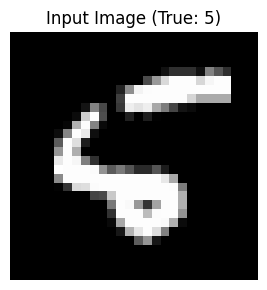

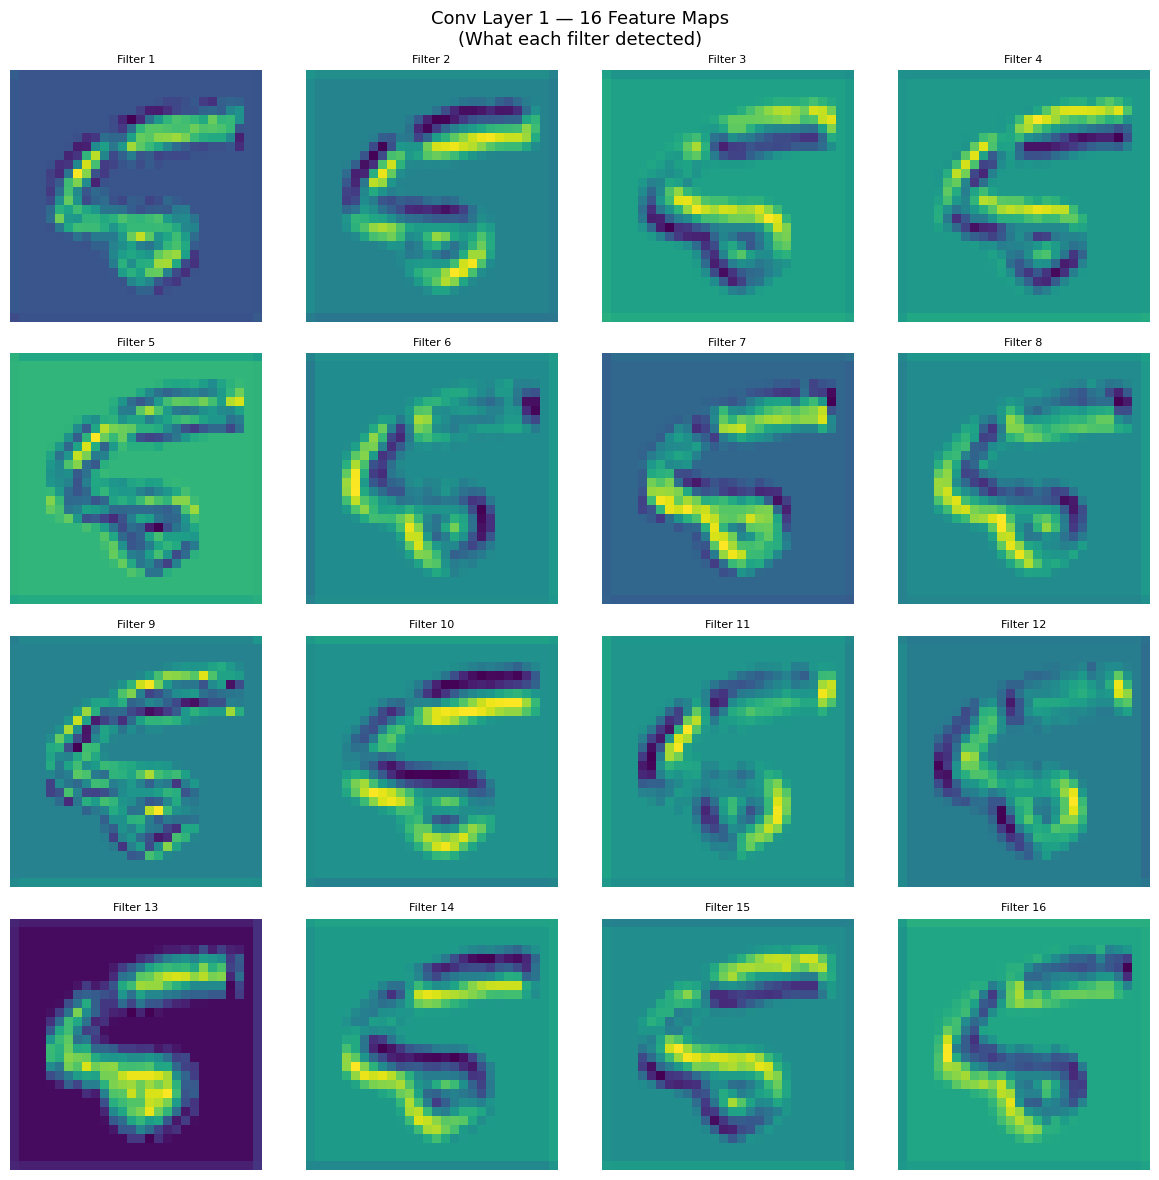

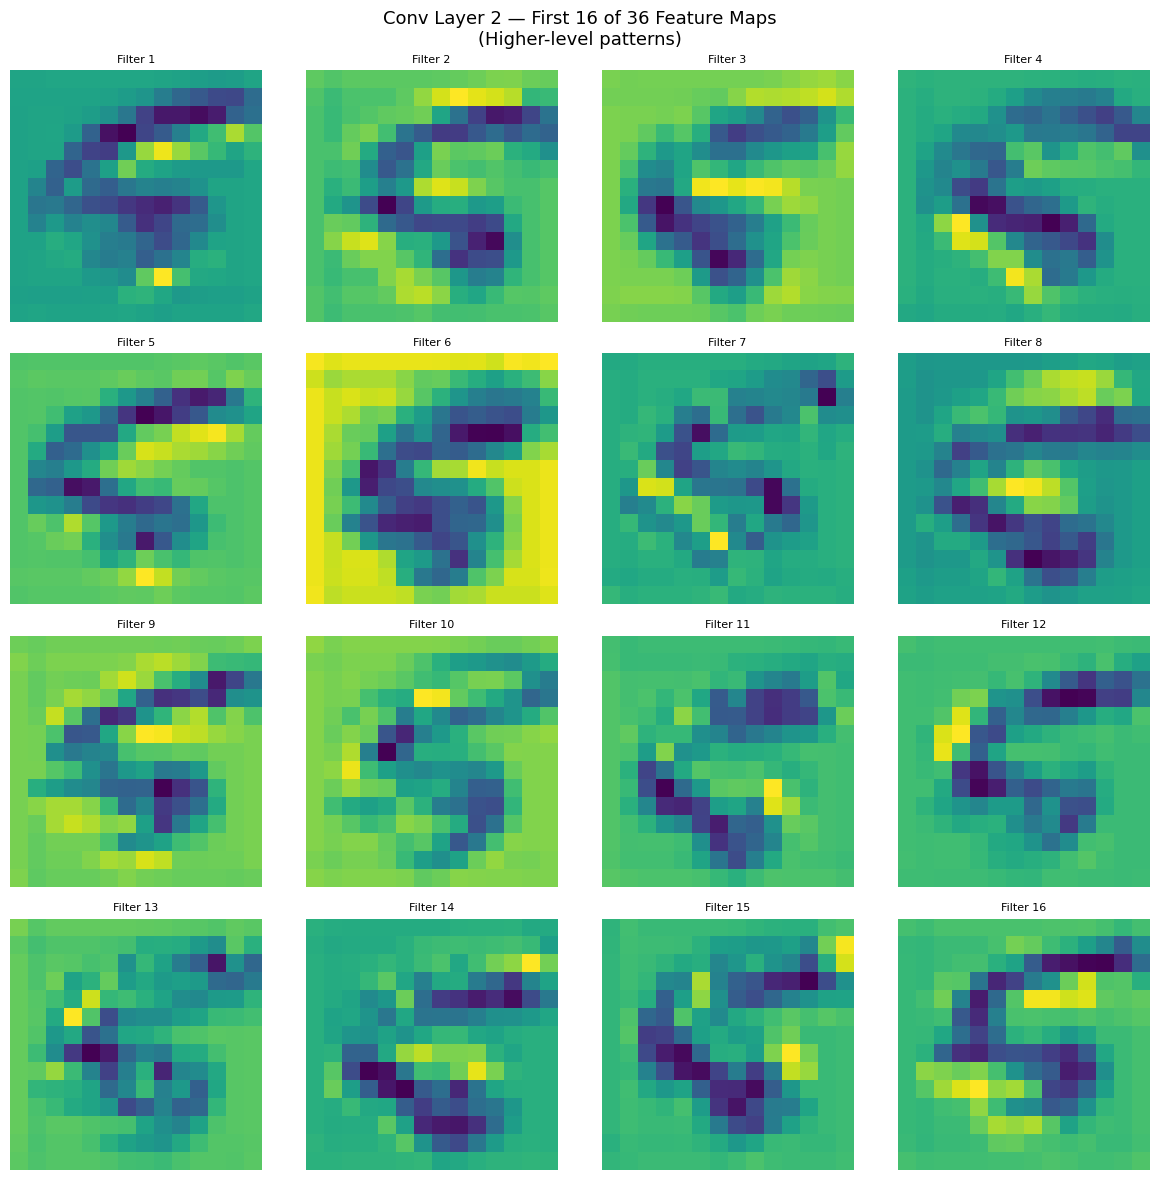

Conv1 filters detect low-level features: edges, curves, gradients.
Conv2 filters detect higher-level patterns: strokes, digit parts.


In [13]:
# Pass one image through the CNN and visualize
# what each filter detected at each conv layer
# This is the most powerful CNN intuition-builder

# Pick one test image — let's use a '5'
sample_img = None
for img, lbl in test_dataset:
    if lbl == 5:
        sample_img = img
        true_lbl   = lbl
        break

sample_tensor = sample_img.unsqueeze(0).to(device)  # (1, 1, 28, 28)

# ── Extract feature maps using hooks ──────────────────────────────────────
feature_maps = {}

def hook_fn(name):
    def hook(module, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook

# Register hooks on both conv layers
hook1 = best_model.conv1.register_forward_hook(hook_fn('conv1'))
hook2 = best_model.conv2.register_forward_hook(hook_fn('conv2'))

# Forward pass — hooks fire automatically
best_model.eval()
with torch.no_grad():
    output = best_model(sample_tensor)
    pred   = torch.argmax(output, dim=1).item()

# Remove hooks
hook1.remove()
hook2.remove()

print(f'True label      : {true_lbl}')
print(f'Predicted label : {pred}')
print(f'Conv1 feature maps shape: {feature_maps["conv1"].shape}')
print(f'Conv2 feature maps shape: {feature_maps["conv2"].shape}')

# ── Plot original image ────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(sample_img.squeeze(), cmap='gray')
ax.set_title(f'Input Image (True: {true_lbl})', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

# ── Plot Conv1 feature maps (16 filters) ──────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i in range(16):
    ax = axes[i // 4][i % 4]
    ax.imshow(feature_maps['conv1'][0, i], cmap='viridis')
    ax.set_title(f'Filter {i+1}', fontsize=8)
    ax.axis('off')
plt.suptitle('Conv Layer 1 — 16 Feature Maps\n(What each filter detected)',
             fontsize=13)
plt.tight_layout()
plt.show()

# ── Plot Conv2 feature maps (first 16 of 36) ──────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i in range(16):
    ax = axes[i // 4][i % 4]
    ax.imshow(feature_maps['conv2'][0, i], cmap='viridis')
    ax.set_title(f'Filter {i+1}', fontsize=8)
    ax.axis('off')
plt.suptitle('Conv Layer 2 — First 16 of 36 Feature Maps\n(Higher-level patterns)',
             fontsize=13)
plt.tight_layout()
plt.show()

print('Conv1 filters detect low-level features: edges, curves, gradients.')
print('Conv2 filters detect higher-level patterns: strokes, digit parts.')






# Visualize CNN feature maps to interpret learned convolutional representations

# - Pass a sample image through the trained CNN and capture the outputs of its convolutional layers.
# - Visualize the feature maps produced by each convolutional filter.
# - Demonstrate how feature representations evolve from low-level visual features to higher-level digit patterns across the network.

# Capture intermediate convolutional activations using forward hooks and visualize the learned feature maps

# - Select a sample image of the handwritten digit "5" from the test dataset and expand its dimensions using `unsqueeze(0)` to create a batch of one image before passing it through the CNN.
#   Example:
#     Original shape : (1, 28, 28)
#     After unsqueeze: (1, 1, 28, 28)
# - Create an empty dictionary (`feature_maps`) to store the outputs of intermediate convolutional layers during inference.
# - Define a hook function (`hook_fn`) that receives the output of a layer during the forward pass and stores the resulting feature maps after moving them to the CPU and detaching them from the computation graph.
# - Register forward hooks on both convolutional layers using `register_forward_hook()`.
#   Example:
#     conv1 ──► Hook stores Conv1 feature maps
#     conv2 ──► Hook stores Conv2 feature maps
#   Hooks allow intermediate layer outputs to be captured automatically without modifying the model's architecture or the `forward()` method.
# - Run the model in evaluation mode (`model.eval()`) and perform a forward pass inside `torch.no_grad()`. During this pass:
#   - The model predicts the digit class.
#   - The registered hooks automatically capture the outputs of `conv1` and `conv2`.
# - Remove the hooks immediately after inference using `remove()` to avoid collecting activations during future forward passes.
# - Print the true label, predicted label, and the shapes of the captured feature maps to verify the intermediate outputs.
#   Example:
#     Conv1 Feature Maps : (1, 16, 28, 28)
#     Conv2 Feature Maps : (1, 36, 14, 14)
# - Display the original handwritten digit for reference before visualizing the learned representations.
# - Plot all 16 feature maps produced by the first convolutional layer. Each feature map corresponds to the response of one learned filter, highlighting simple visual patterns such as edges, curves, or intensity gradients present in the input image.
# - Plot the first 16 feature maps from the second convolutional layer. These feature maps represent more abstract visual patterns created by combining the low-level features extracted in the first convolutional layer.
#   Example:
#     Conv1 detects:
#       - Vertical edges
#       - Horizontal edges
#       - Curves
#       - Corners

#     Conv2 detects:
#       - Loops
#       - Stroke intersections
#       - Portions of handwritten digits
#       - Complex digit structures
# - Use these visualizations to demonstrate the hierarchical learning process of CNNs, where earlier layers capture simple image features while deeper layers learn increasingly meaningful and task-specific representations that support accurate digit classification.

In [14]:
print('=' * 60)
print('        EXPERIMENT 4 (LAB 4) — FINAL SUMMARY')
print('=' * 60)
print(f'Dataset         : MNIST (60,000 train / 10,000 test)')
print(f'Task            : Handwritten Digit Classification (0–9)')
print()
print(f'--- Model Comparison ---')
print(f'{"Model":<25} {"Params":>10} {"Test Acc":>10}')
print('-' * 48)
dnn_params = sum(p.numel() for p in dnn_model.parameters())
cnn_params = sum(p.numel() for p in cnn_model.parameters())
print(f'{"DNN (SGD, 5 epochs)":<25} {dnn_params:>10,} {dnn_test_accs[-1]*100:>9.2f}%')
print(f'{"CNN (SGD, 7 epochs)":<25} {cnn_params:>10,} {cnn_test_accs[-1]*100:>9.2f}%')
print(f'{"CNN (RMSProp, 7 epochs)":<25} {cnn_params:>10,} {99.13:>9.2f}%')
print()
print(f'--- Optimizer Comparison (CNN, 5 epochs) ---')
for opt_name, results in optimizer_results.items():
    print(f'  {opt_name:<25} : {results["test_accs"][-1]*100:.2f}%')
print()
print(f'--- Per-Class Hardest Digits ---')
print(f'  Easiest : Digit 0  (99.69% accuracy)')
print(f'  Hardest : Digit 9  (98.32% accuracy)')
print(f'  Most confused pair: 6 ↔ 9  (visually similar)')
print()
print(f'--- Key Findings ---')
print(f'  ✓ CNN outperforms DNN despite fewer parameters')
print(f'  ✓ RMSProp > Adam > SGD for this task')
print(f'  ✓ Adaptive optimizers converge faster and reach higher accuracy')
print(f'  ✓ Conv1 learned edge/gradient detectors')
print(f'  ✓ Conv2 learned higher-level stroke patterns')
print(f'  ✓ Only {len(misclassified_indices)} misclassified out of 10,000 test images')
print('=' * 60)

        EXPERIMENT 4 (LAB 4) — FINAL SUMMARY
Dataset         : MNIST (60,000 train / 10,000 test)
Task            : Handwritten Digit Classification (0–9)

--- Model Comparison ---
Model                         Params   Test Acc
------------------------------------------------
DNN (SGD, 5 epochs)          101,770     97.78%
CNN (SGD, 7 epochs)          232,590     98.19%
CNN (RMSProp, 7 epochs)      232,590     99.13%

--- Optimizer Comparison (CNN, 5 epochs) ---
  SGD (lr=0.01)             : 97.61%
  Adam (lr=0.001)           : 98.89%
  RMSProp (lr=0.001)        : 99.12%

--- Per-Class Hardest Digits ---
  Easiest : Digit 0  (99.69% accuracy)
  Hardest : Digit 9  (98.32% accuracy)
  Most confused pair: 6 ↔ 9  (visually similar)

--- Key Findings ---
  ✓ CNN outperforms DNN despite fewer parameters
  ✓ RMSProp > Adam > SGD for this task
  ✓ Adaptive optimizers converge faster and reach higher accuracy
  ✓ Conv1 learned edge/gradient detectors
  ✓ Conv2 learned higher-level stroke patte